# WildScan training script - Tyler Clinscales, Geoffrey Fadera, Edwin Merchan
##### (scratch ResNet + MixUp + OneCycleLR)

### What this does
- Builds a 20-class label map from Caltech COCO-style JSONs
- Trains a small ResNet-from-scratch with standard augs + MixUp
- Logs to TensorBoard, checkpoints each epoch, and supports resume
----------
### Notes for reviewers
- Windows users: keep num_workers=0 (multiprocessing is tricky on Windows)
- Checkpoint contains model/optimizer/scheduler states; safe to resume
- We intentionally *don’t* use class-balancing here; see team thread for why
"""

In [15]:
import json
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from torch.utils.tensorboard import SummaryWriter

In [16]:
# TensorBoard run dir (separate from the training loop's writer below)
writer = SummaryWriter("runs/wildscan_full_scratch_csv")

In [17]:
# --- Device selection -------------------------------------------------
# CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [18]:
# --- Data sources ------------------------------------------
# Paths to COCO-style files and the (already cropped) images.
# BASE_DIR structure expected:
#   cropped_images/
#     train/*.jpg
#     val/*.jpg

META_JSON = Path(r"C:/Users/T/Documents/WildScan/annotations/caltech_images_20210113.json")
BBOX_JSON = Path(r"C:/Users/T/Documents/WildScan/annotations/caltech_bboxes.json")
BASE_DIR  = Path(r"C:/Users/T/Documents/WildScan/cropped_images")

In [19]:
# --- Build filename → label index map FROM YOUR CSVS (14 classes) ------------
# Uses columns: filename,label  (exactly as in your sample)
import pandas as pd
from pathlib import Path

def _basename_lower(x: str) -> str:
    return Path(str(x)).name.strip().lower()

def _orig_from_crop(name: str) -> str:
    # 'foo_3.jpg' -> 'foo.jpg'; if no underscore, unchanged
    p = Path(name)
    stem, ext = p.stem, p.suffix
    if "_" in stem:
        return stem.rsplit("_", 1)[0] + ext
    return p.name

# Load your splits
df_tr = pd.read_csv("train-meta.csv")[["filename", "label"]].copy()
df_va = pd.read_csv("val-meta.csv")[["filename", "label"]].copy()

# Normalize names/labels
for df in (df_tr, df_va):
    df["filename"] = df["filename"].astype(str).map(_basename_lower)
    df["label"]    = df["label"].astype(str).str.strip()

# Define class set from both CSVs (this will be your 14 classes)
df_all  = pd.concat([df_tr, df_va], ignore_index=True)
classes = sorted(df_all["label"].unique().tolist())
class2idx = {c: i for i, c in enumerate(classes)}
print(f"Found {len(classes)} classes from CSVs: {classes}")

# filename -> class_idx
label_map = {}
for row in df_all.itertuples(index=False):
    fname = row.filename
    idx   = class2idx[row.label]
    label_map[fname] = idx
    label_map[_orig_from_crop(fname)] = idx

# Sets for filtering the file lists below
csv_train_names = set(df_tr["filename"].tolist())
csv_val_names   = set(df_va["filename"].tolist())

Found 14 classes from CSVs: ['bird', 'bobcat', 'car', 'cat', 'coyote', 'deer', 'dog', 'fox', 'opossum', 'rabbit', 'raccoon', 'rodent', 'skunk', 'squirrel']


In [20]:
# --- Transforms ------------------------------------------------
# Keep training/val transforms standard and ImageNet-normalized.

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

In [21]:
# --- Dataset --------------------------------------------------------------
class WildScanDataset(Dataset):
    """
    Loads pre-cropped .jpgs and looks up labels by mapping the crop name
    back to the original filename.

    Crop filename convention:
      <orig_basename>_<N>.jpg  -> label of <orig_basename>.jpg
    If no underscore is present, we assume the file itself is the original.
    """
    def __init__(self, img_dir, label_map, transform=None):
        self.img_paths = list(Path(img_dir).glob("*.jpg"))
        self.label_map = label_map
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        # Recover original filename from crop name (e.g., foo_3.jpg -> foo.jpg):
        fname = img_path.name
        if "_" in fname:
            orig = fname.rsplit("_", 1)[0] + ".jpg"
        else:
            orig = fname

        # Lookup class index; raise with a helpful message if missing.
        try:
            label = self.label_map[orig]
        except KeyError:
            raise KeyError(f"No label for crop {fname}; looked up as {orig}")

        return img, label

In [22]:
# --- DataLoaders ---------------------------------------------------------
# Windows + single-process dataloading: num_workers=0 avoids issues.

train_ds = WildScanDataset(BASE_DIR/"train", label_map, transform=train_tf)
val_ds   = WildScanDataset(BASE_DIR/"val",   label_map, transform=val_tf)

from itertools import chain

# Index BOTH folders so we can resolve any filename by name
all_paths = {}
for p in chain((BASE_DIR/"train").glob("*.jpg"), (BASE_DIR/"val").glob("*.jpg")):
    all_paths[p.name.lower()] = p

before_train, before_val = len(train_ds.img_paths), len(val_ds.img_paths)
train_ds.img_paths = [all_paths[n] for n in csv_train_names if n in all_paths]
val_ds.img_paths   = [all_paths[n] for n in csv_val_names   if n in all_paths]

print(f"CSV filter (both dirs) → train: {before_train} → {len(train_ds.img_paths)} | "
      f"val: {before_val} → {len(val_ds.img_paths)}")


train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)
val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

CSV filter (both dirs) → train: 39372 → 9088 | val: 25763 → 1463


In [23]:
# --- Small baseline CNN (for quick runs / sanity checks) ---
class CustomCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc1 = nn.Sequential(
            nn.Linear(64 * 56 * 56, 256),
            nn.Dropout(dropout),
            nn.ReLU()
        )
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return self.fc2(x)

model = CustomCNN(num_classes=len(classes)).to(device)

In [24]:
# --- Basic training setup for the baseline model --------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [26]:
# Best settings from Optuna
best_lr   = 4.0768585062536436e-05
best_wd   = 8.640550991403599e-05
best_drop = 0.32730052965450074
best_bs   = 32
best_er_p = 0.3383625455277442

In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curves(hist):
    # One plot per chart (no subplots)
    plt.figure()
    plt.title("Training vs Validation Accuracy")
    plt.plot(hist["epoch"], hist["train_acc"], label="train")
    plt.plot(hist["epoch"], hist["val_acc"], label="val")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend(); plt.grid(True)
    plt.show()

    plt.figure()
    plt.title("Training Loss")
    plt.plot(hist["epoch"], hist["train_loss"], label="train loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True)
    plt.show()

    plt.figure()
    plt.title("Learning Rate (epoch-end)")
    plt.plot(hist["epoch"], hist["lr"], label="lr")
    plt.xlabel("Epoch"); plt.ylabel("LR")
    plt.legend(); plt.grid(True)
    plt.show()

def plot_confusion_matrix(cm, class_names):
    # Normalize rows (per true class)
    cmn = cm.astype(np.float64)
    row_sums = cmn.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    cmn = cmn / row_sums

    plt.figure()
    plt.title("Confusion Matrix (Normalized)")
    plt.imshow(cmn, aspect='auto')
    plt.colorbar()
    plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=90)
    plt.yticks(ticks=np.arange(len(class_names)), labels=class_names)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.show()


CSV filter → train: 9088 → 9088 | val: 1463 → 1463


Epoch 1/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 1/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 1: Loss 1.8918 | Train Acc 0.364 | Val Acc 0.370


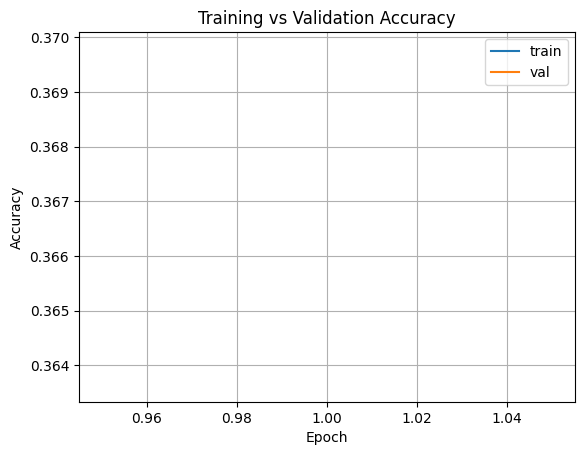

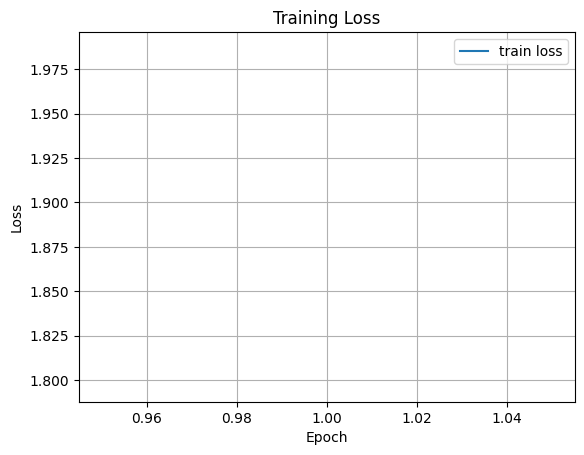

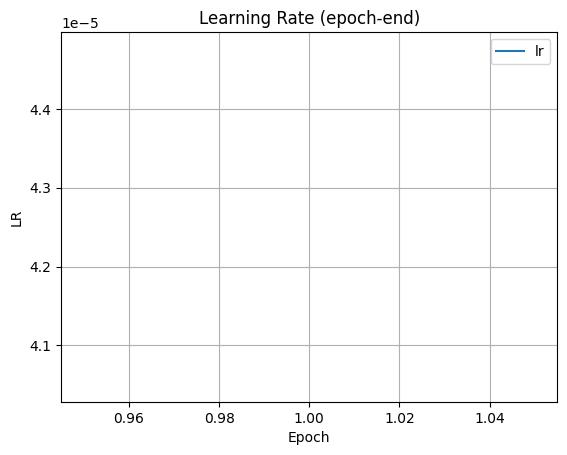

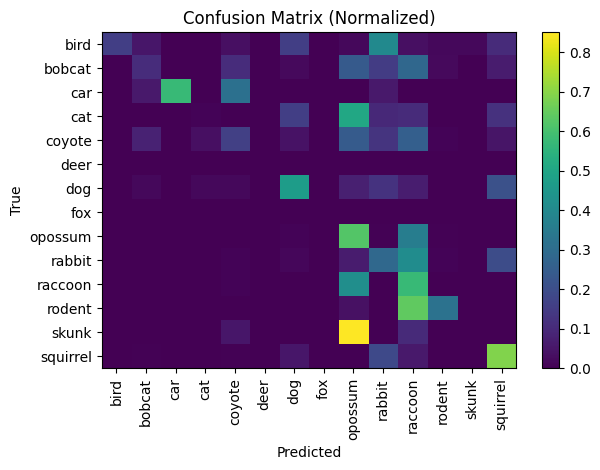

Epoch 1: Loss 1.8918 | Train Acc 0.364 | Val Acc 0.370


Epoch 2/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 2/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 2: Loss 1.7012 | Train Acc 0.428 | Val Acc 0.502
Epoch 2: Loss 1.7012 | Train Acc 0.428 | Val Acc 0.502


Epoch 3/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

...

Epoch 4/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 4: Loss 1.5142 | Train Acc 0.520 | Val Acc 0.580
Epoch 4: Loss 1.5142 | Train Acc 0.520 | Val Acc 0.580


Epoch 5/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 5/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 5: Loss 1.4647 | Train Acc 0.538 | Val Acc 0.571


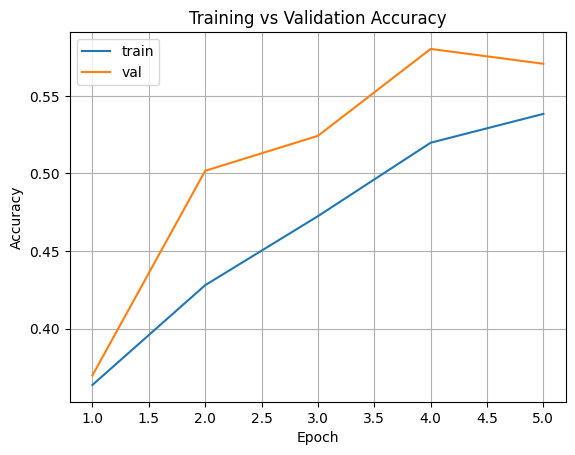

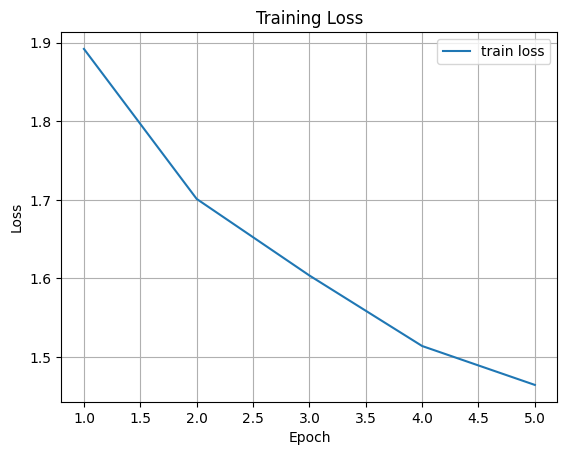

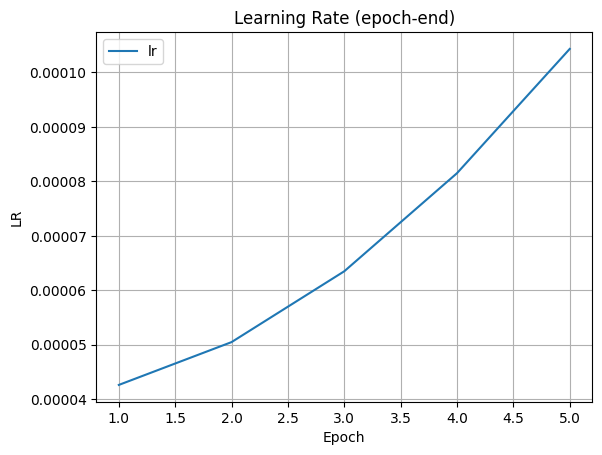

Epoch 5: Loss 1.4647 | Train Acc 0.538 | Val Acc 0.571


Epoch 6/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 6/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 6: Loss 1.3507 | Train Acc 0.584 | Val Acc 0.580
Epoch 6: Loss 1.3507 | Train Acc 0.584 | Val Acc 0.580


Epoch 7/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

...

Epoch 9/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 9: Loss 1.2726 | Train Acc 0.623 | Val Acc 0.648
Epoch 9: Loss 1.2726 | Train Acc 0.623 | Val Acc 0.648


Epoch 10/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 10/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 10: Loss 1.2695 | Train Acc 0.615 | Val Acc 0.665


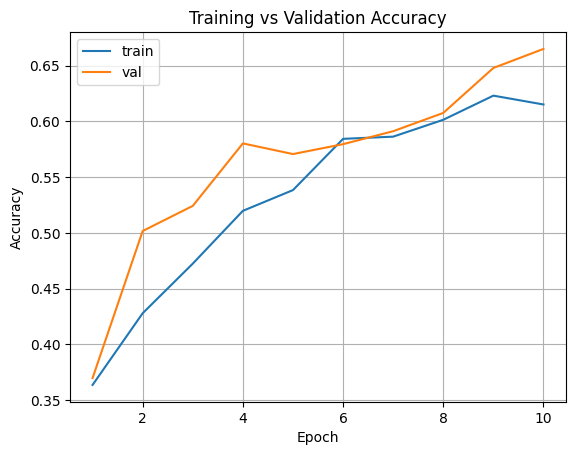

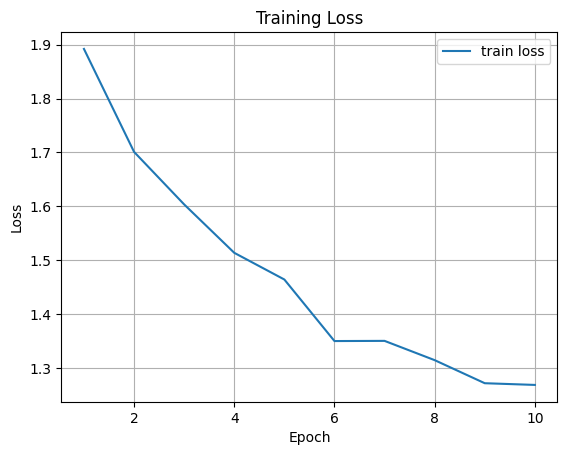

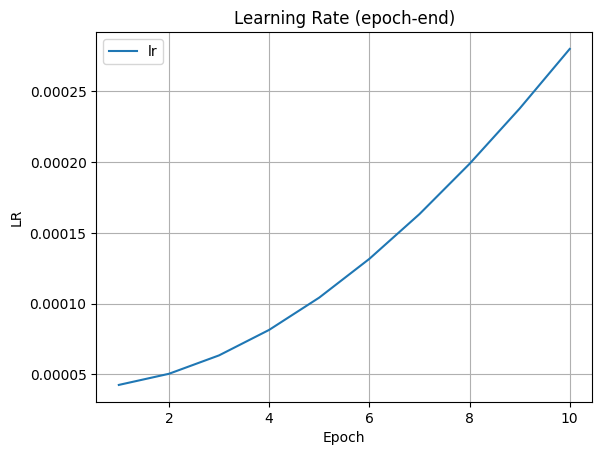

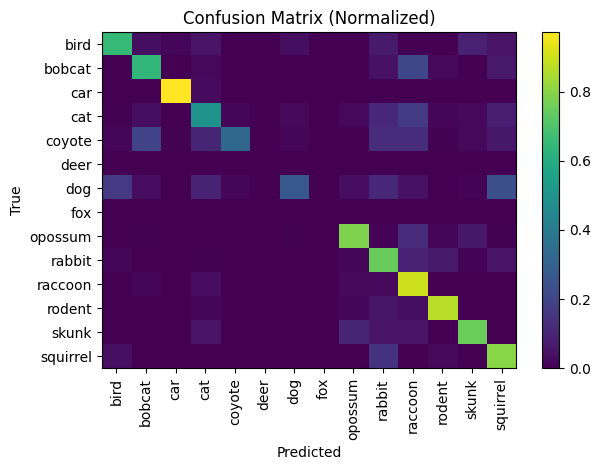

Epoch 10: Loss 1.2695 | Train Acc 0.615 | Val Acc 0.665


Epoch 11/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 11/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 11: Loss 1.2292 | Train Acc 0.638 | Val Acc 0.669
Epoch 11: Loss 1.2292 | Train Acc 0.638 | Val Acc 0.669


Epoch 12/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

...

Epoch 14/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 14: Loss 1.1916 | Train Acc 0.654 | Val Acc 0.647
Epoch 14: Loss 1.1916 | Train Acc 0.654 | Val Acc 0.647


Epoch 15/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 15/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 15: Loss 1.1879 | Train Acc 0.653 | Val Acc 0.670


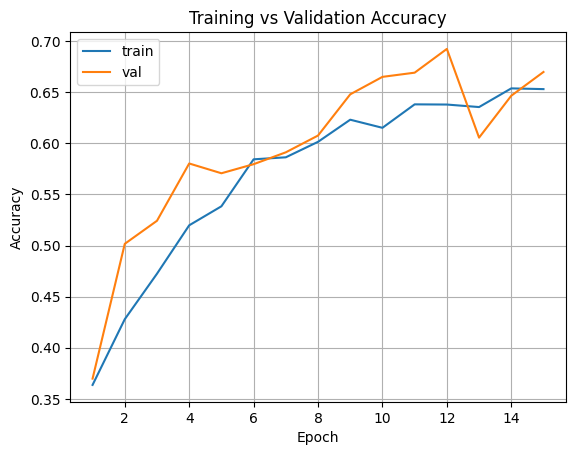

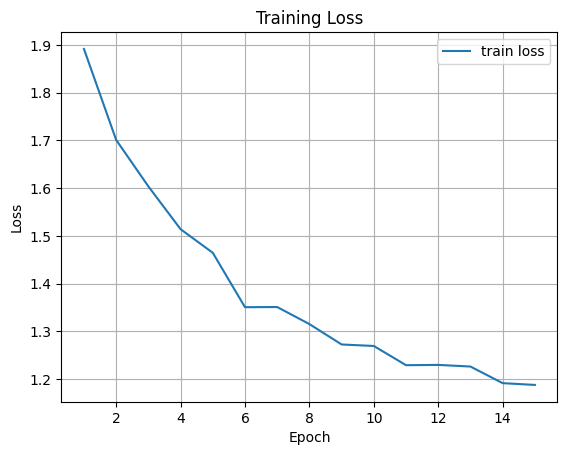

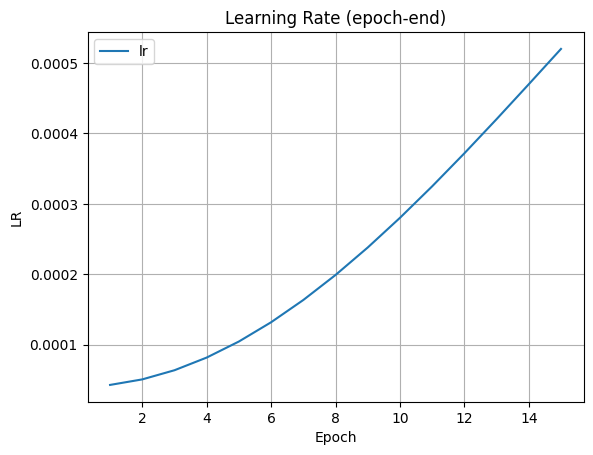

Epoch 15: Loss 1.1879 | Train Acc 0.653 | Val Acc 0.670


Epoch 16/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 16/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 16: Loss 1.1725 | Train Acc 0.658 | Val Acc 0.710
Epoch 16: Loss 1.1725 | Train Acc 0.658 | Val Acc 0.710


Epoch 17/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

...

Epoch 19/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 19: Loss 1.1666 | Train Acc 0.662 | Val Acc 0.636
Epoch 19: Loss 1.1666 | Train Acc 0.662 | Val Acc 0.636


Epoch 20/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 20/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 20: Loss 1.1107 | Train Acc 0.681 | Val Acc 0.692


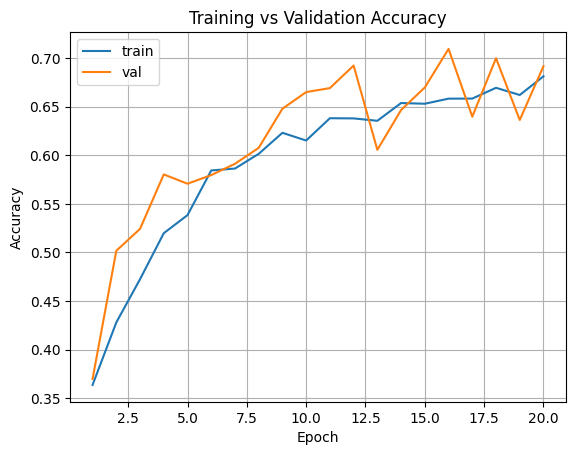

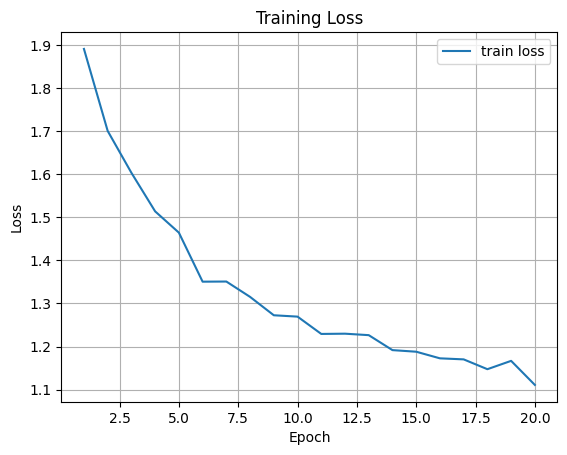

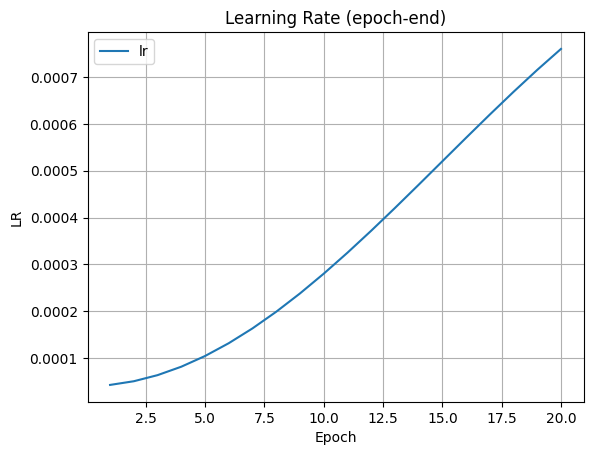

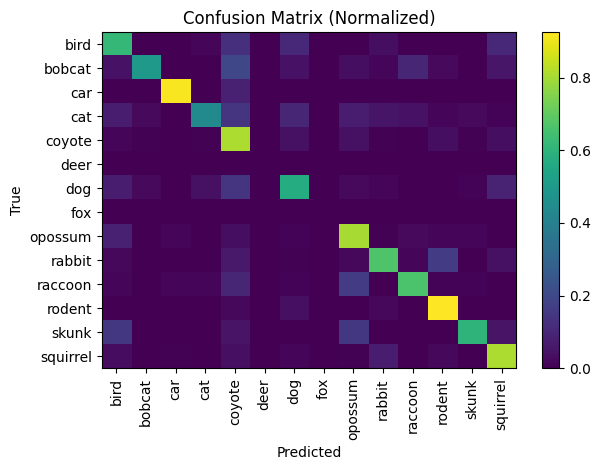

Epoch 20: Loss 1.1107 | Train Acc 0.681 | Val Acc 0.692


Epoch 21/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 21/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 21: Loss 1.1419 | Train Acc 0.669 | Val Acc 0.712
Epoch 21: Loss 1.1419 | Train Acc 0.669 | Val Acc 0.712


Epoch 22/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

...

Epoch 24/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 24: Loss 1.1373 | Train Acc 0.678 | Val Acc 0.700
Epoch 24: Loss 1.1373 | Train Acc 0.678 | Val Acc 0.700


Epoch 25/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 25/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 25: Loss 1.0878 | Train Acc 0.691 | Val Acc 0.746


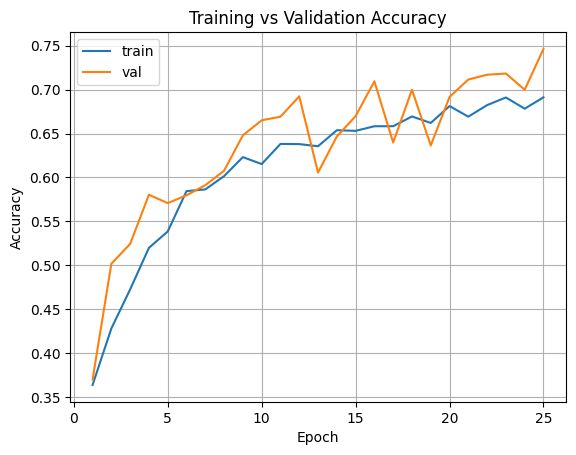

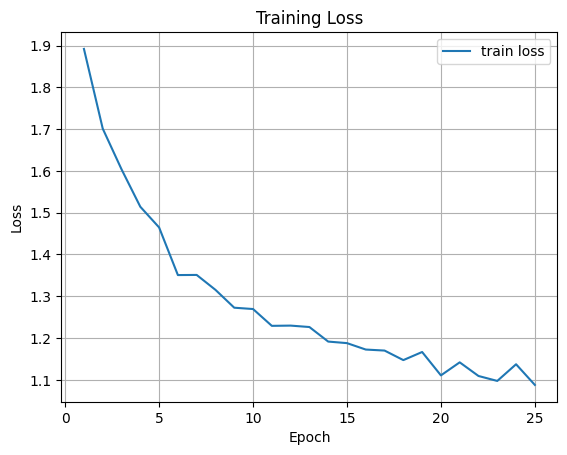

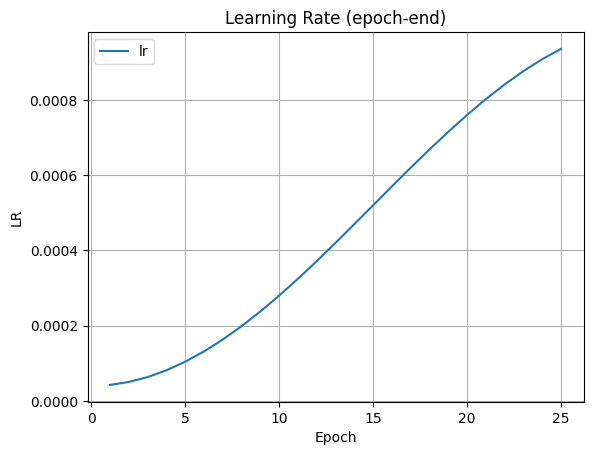

Epoch 25: Loss 1.0878 | Train Acc 0.691 | Val Acc 0.746


Epoch 26/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 26/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 26: Loss 1.0830 | Train Acc 0.693 | Val Acc 0.712
Epoch 26: Loss 1.0830 | Train Acc 0.693 | Val Acc 0.712


Epoch 27/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

...

Epoch 29/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 29: Loss 1.1281 | Train Acc 0.680 | Val Acc 0.690
Epoch 29: Loss 1.1281 | Train Acc 0.680 | Val Acc 0.690


Epoch 30/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 30/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 30: Loss 1.0676 | Train Acc 0.696 | Val Acc 0.729


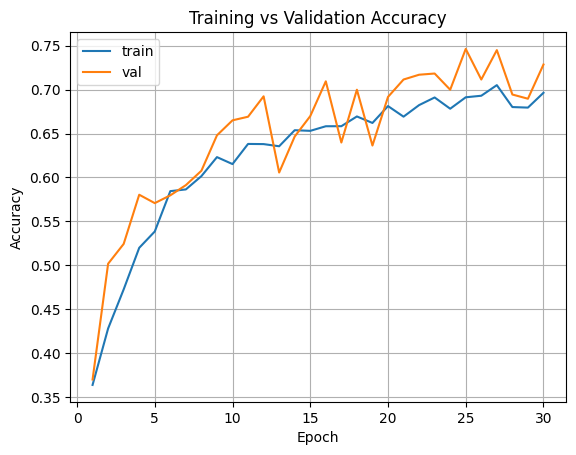

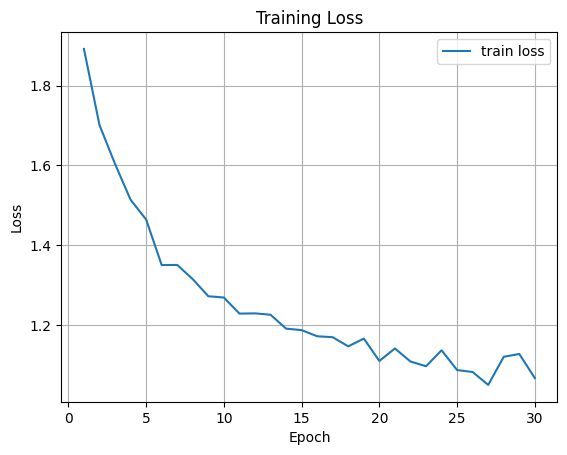

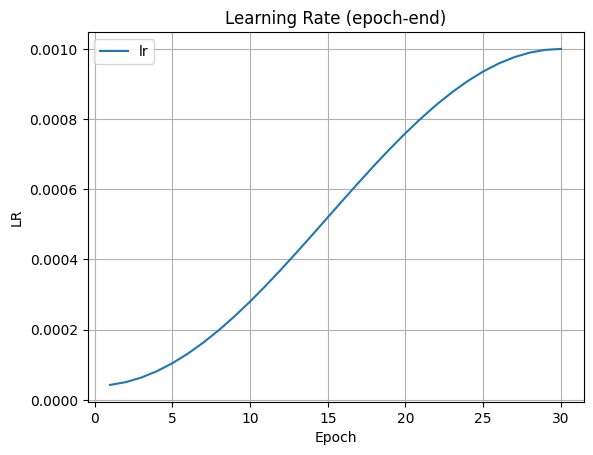

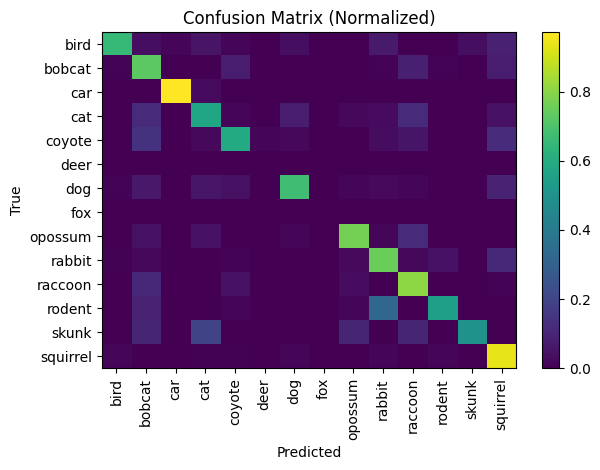

Epoch 30: Loss 1.0676 | Train Acc 0.696 | Val Acc 0.729


Epoch 31/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 31/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 31: Loss 1.0920 | Train Acc 0.688 | Val Acc 0.637
Epoch 31: Loss 1.0920 | Train Acc 0.688 | Val Acc 0.637


Epoch 32/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

...

Epoch 34/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 34: Loss 0.9968 | Train Acc 0.718 | Val Acc 0.747
Epoch 34: Loss 0.9968 | Train Acc 0.718 | Val Acc 0.747


Epoch 35/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 35/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 35: Loss 0.9879 | Train Acc 0.721 | Val Acc 0.721


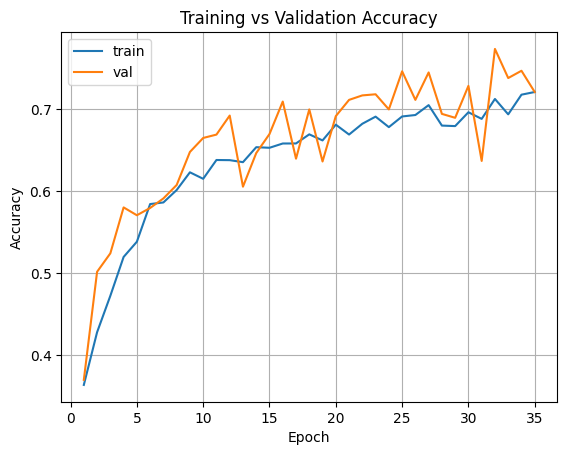

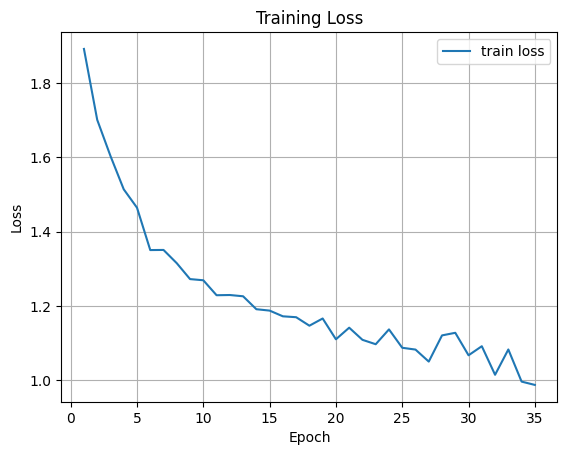

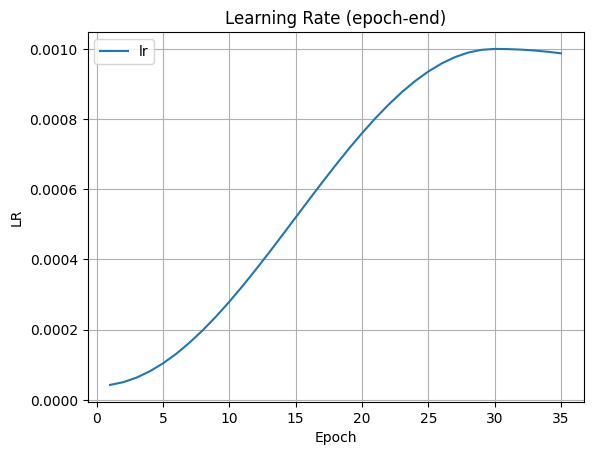

Epoch 35: Loss 0.9879 | Train Acc 0.721 | Val Acc 0.721


Epoch 36/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 36/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 36: Loss 0.9784 | Train Acc 0.721 | Val Acc 0.693
Epoch 36: Loss 0.9784 | Train Acc 0.721 | Val Acc 0.693


Epoch 37/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

...

Epoch 39/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 39: Loss 0.9953 | Train Acc 0.717 | Val Acc 0.720
Epoch 39: Loss 0.9953 | Train Acc 0.717 | Val Acc 0.720


Epoch 40/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 40/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 40: Loss 0.9573 | Train Acc 0.733 | Val Acc 0.715


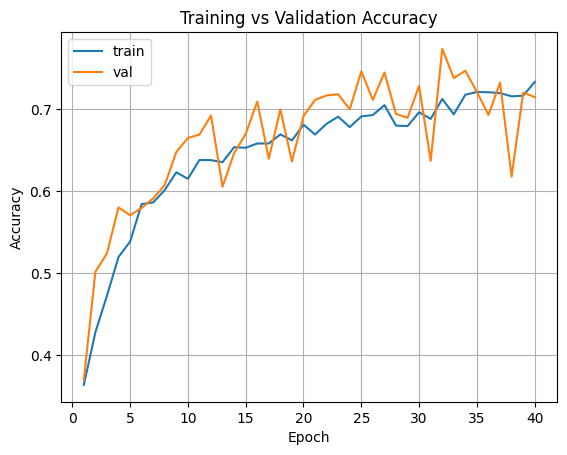

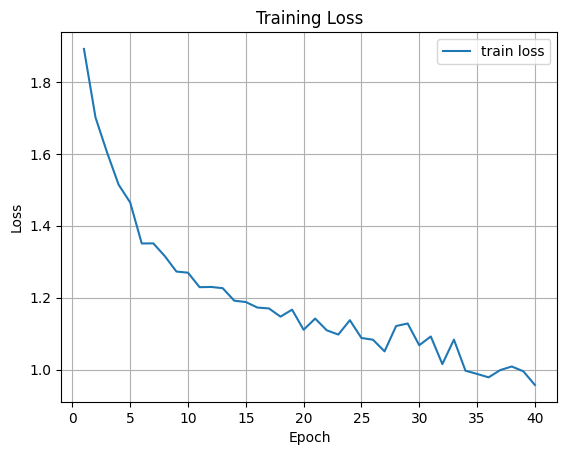

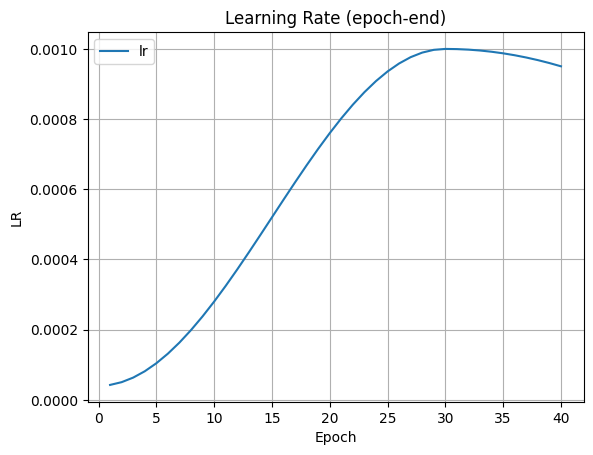

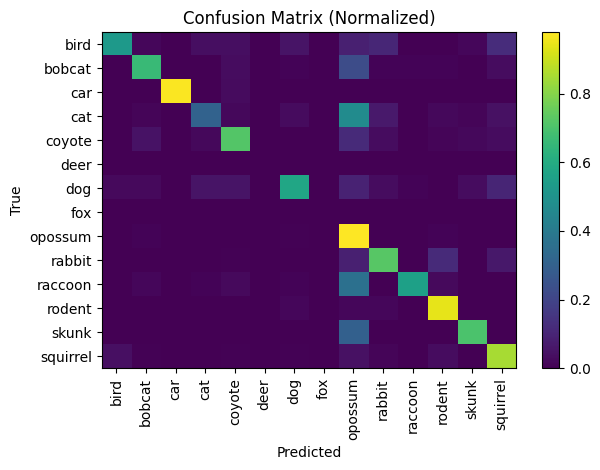

Epoch 40: Loss 0.9573 | Train Acc 0.733 | Val Acc 0.715


Epoch 41/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 41/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 41: Loss 0.9325 | Train Acc 0.737 | Val Acc 0.733
Epoch 41: Loss 0.9325 | Train Acc 0.737 | Val Acc 0.733


Epoch 42/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

...

Epoch 44/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 44: Loss 0.8915 | Train Acc 0.753 | Val Acc 0.720
Epoch 44: Loss 0.8915 | Train Acc 0.753 | Val Acc 0.720


Epoch 45/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 45/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 45: Loss 0.9595 | Train Acc 0.730 | Val Acc 0.689


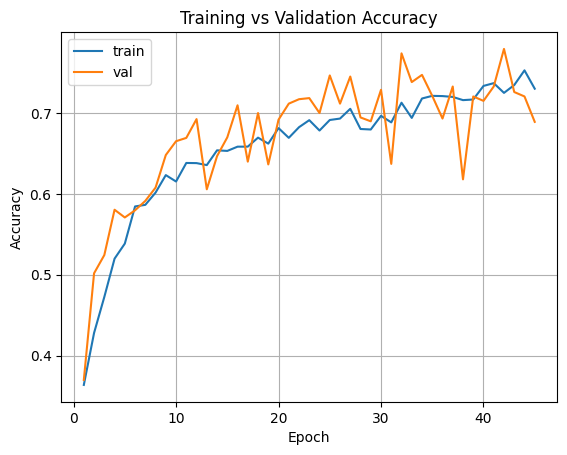

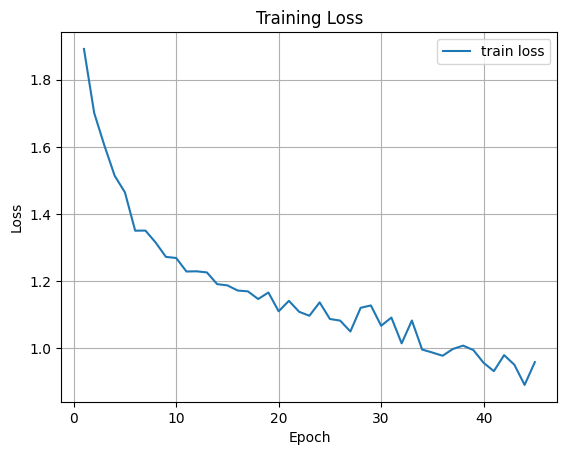

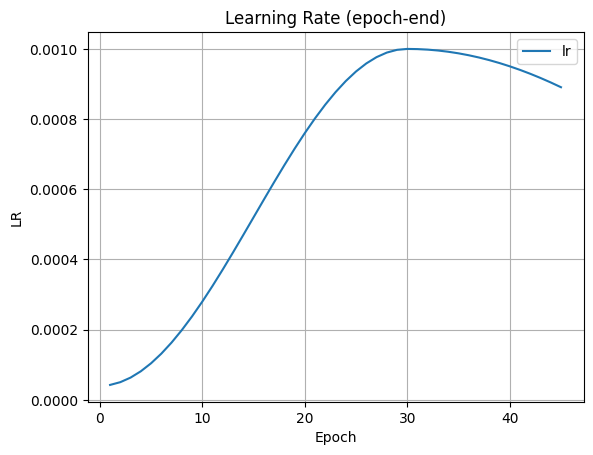

Epoch 45: Loss 0.9595 | Train Acc 0.730 | Val Acc 0.689


Epoch 46/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 46/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 46: Loss 0.8750 | Train Acc 0.757 | Val Acc 0.744
Epoch 46: Loss 0.8750 | Train Acc 0.757 | Val Acc 0.744


Epoch 47/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

...

Epoch 49/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 49: Loss 0.9029 | Train Acc 0.753 | Val Acc 0.775
Epoch 49: Loss 0.9029 | Train Acc 0.753 | Val Acc 0.775


Epoch 50/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 50/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 50: Loss 0.9345 | Train Acc 0.740 | Val Acc 0.837


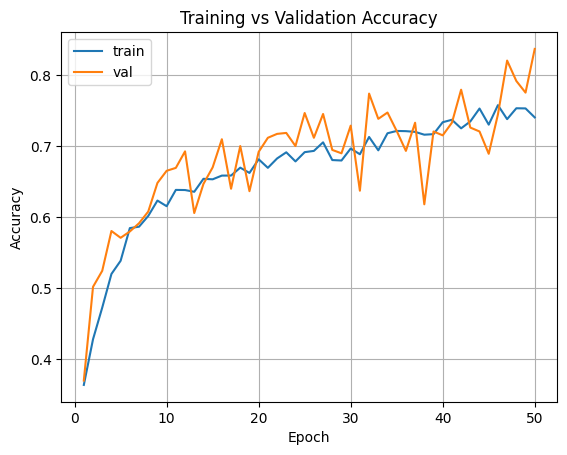

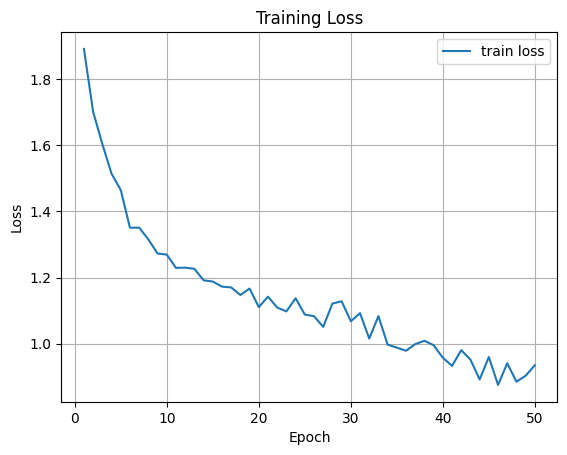

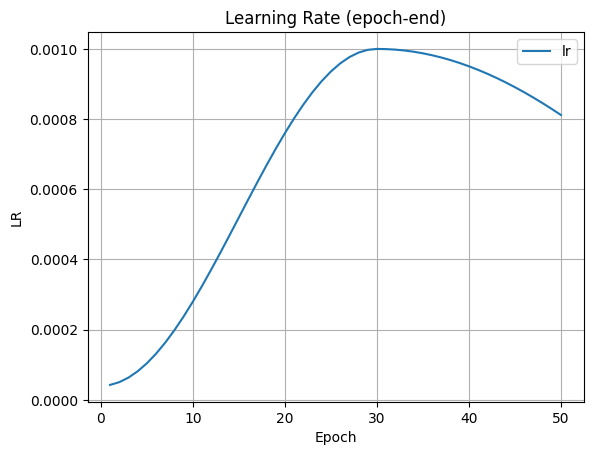

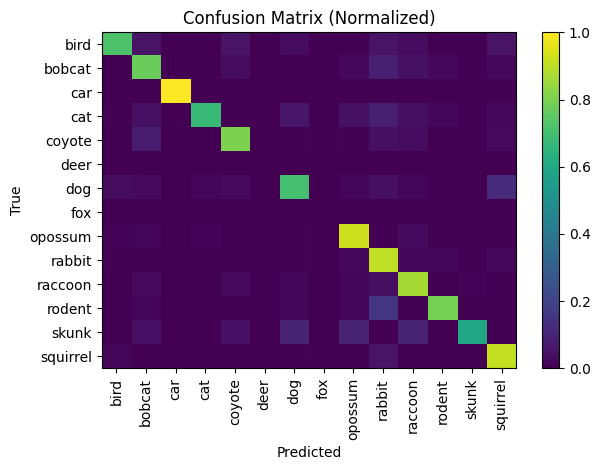

Epoch 50: Loss 0.9345 | Train Acc 0.740 | Val Acc 0.837


Epoch 51/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 51/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 51: Loss 0.8615 | Train Acc 0.762 | Val Acc 0.826
Epoch 51: Loss 0.8615 | Train Acc 0.762 | Val Acc 0.826


Epoch 52/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

...

Epoch 54/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 54: Loss 0.8450 | Train Acc 0.771 | Val Acc 0.792
Epoch 54: Loss 0.8450 | Train Acc 0.771 | Val Acc 0.792


Epoch 55/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 55/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 55: Loss 0.9011 | Train Acc 0.757 | Val Acc 0.808


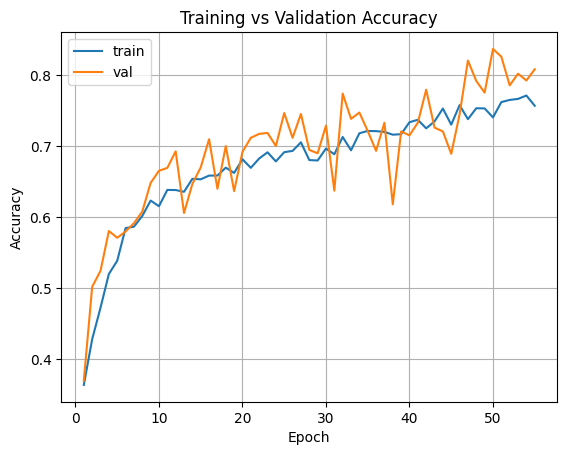

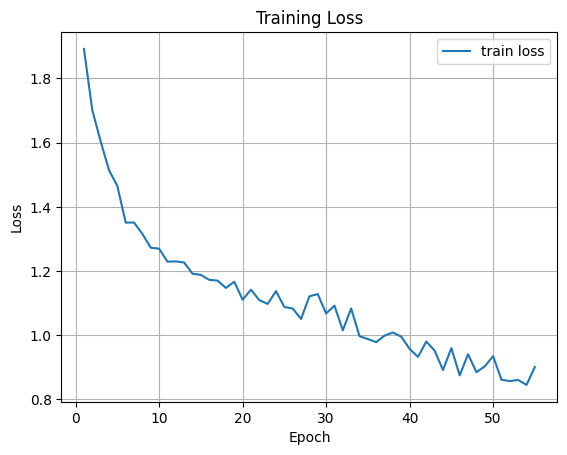

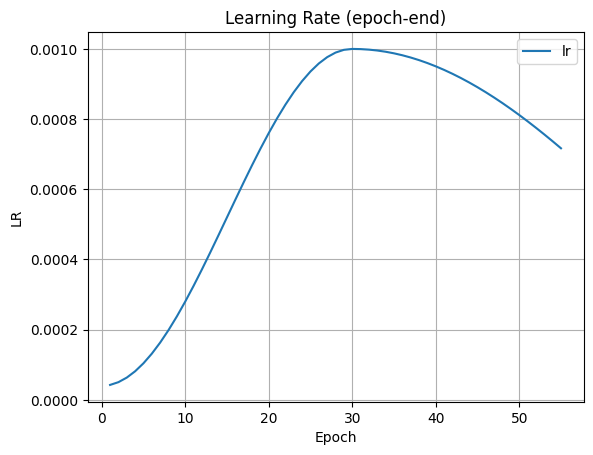

Epoch 55: Loss 0.9011 | Train Acc 0.757 | Val Acc 0.808


Epoch 56/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 56/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 56: Loss 0.8669 | Train Acc 0.760 | Val Acc 0.817
Epoch 56: Loss 0.8669 | Train Acc 0.760 | Val Acc 0.817


Epoch 57/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

...

Epoch 59/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 59: Loss 0.8013 | Train Acc 0.784 | Val Acc 0.826
Epoch 59: Loss 0.8013 | Train Acc 0.784 | Val Acc 0.826


Epoch 60/100 [Train]:   0%|          | 0/284 [00:00<?, ?it/s]

Epoch 60/100 [Val ]:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 60: Loss 0.8157 | Train Acc 0.780 | Val Acc 0.820


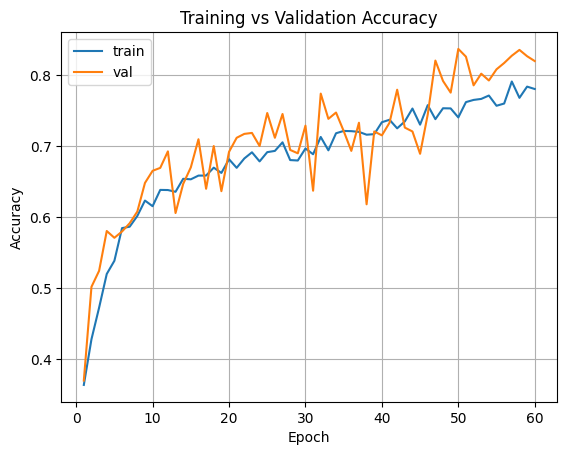

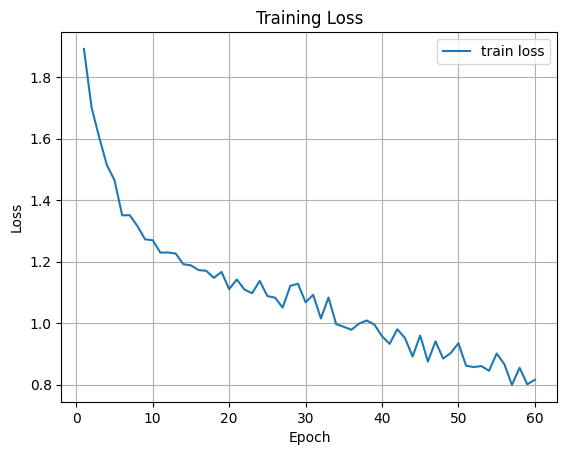

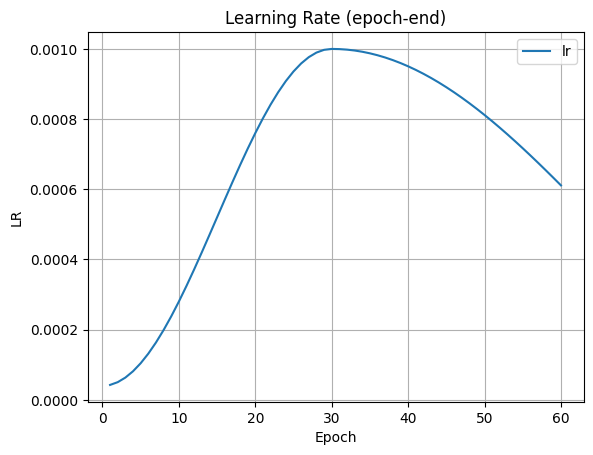

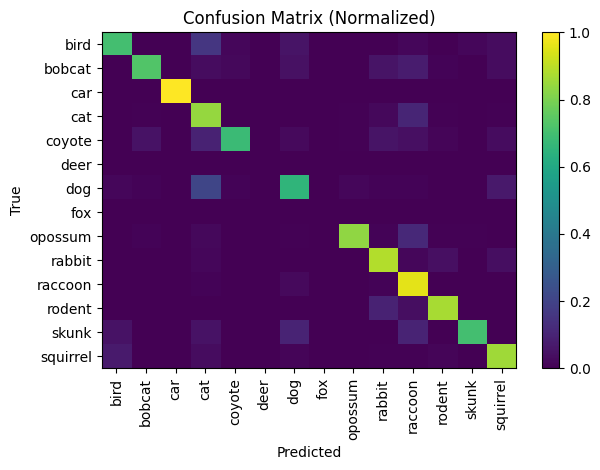

Epoch 60: Loss 0.8157 | Train Acc 0.780 | Val Acc 0.820
No ≥0.1% gain for 10 epochs—stopping.
Done! Best val acc: 0.8366


In [28]:
# The following section is the "full" training setup with ScratchResNet,
# MixUp, OneCycleLR, early stopping, and checkpoint resume. It’s the path we currently use for main experiments.

from pathlib import Path
import os, random, numpy as np, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# --- Reproducibility & a dedicated TB writer ------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
writer = SummaryWriter("runs/wildscan_full_scratch_csv")

def plot_learning_curves(hist):
    plt.figure()
    plt.title("Training vs Validation Accuracy")
    plt.plot(hist["epoch"], hist["train_acc"], label="train")
    plt.plot(hist["epoch"], hist["val_acc"], label="val")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend(); plt.grid(True)
    plt.show()

    plt.figure()
    plt.title("Training Loss")
    plt.plot(hist["epoch"], hist["train_loss"], label="train loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True)
    plt.show()

    plt.figure()
    plt.title("Learning Rate (epoch-end)")
    plt.plot(hist["epoch"], hist["lr"], label="lr")
    plt.xlabel("Epoch"); plt.ylabel("LR")
    plt.legend(); plt.grid(True)
    plt.show()

def plot_confusion_matrix(cm, class_names):
    # Normalize rows (per true class)
    cmn = cm.astype(np.float64)
    row_sums = cmn.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    cmn = cmn / row_sums

    plt.figure()
    plt.title("Confusion Matrix (Normalized)")
    plt.imshow(cmn, aspect='auto')
    plt.colorbar()
    plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=90)
    plt.yticks(ticks=np.arange(len(class_names)), labels=class_names)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.show()

# --- MixUp helpers ---------------
def mixup_data(x, y, alpha=0.4):
    if alpha > 0:
        lam = torch.distributions.Beta(alpha, alpha).sample().item()
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(crit, pred, y_a, y_b, lam):
    return lam * crit(pred, y_a) + (1 - lam) * crit(pred, y_b)

# --- Scratch ResNet (small) ------------------------------------
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_c)
        self.down  = downsample

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.down: identity = self.down(x)
        return F.relu(out + identity)

class ScratchResNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, 2, 3, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(3, 2, 1)
        )
        self.layer1 = self._make_layer(64, 64, 2)
        self.layer2 = self._make_layer(64,128,2, stride=2)
        self.layer3 = self._make_layer(128,256,2, stride=2)
        self.layer4 = self._make_layer(256,512,2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(512, num_classes)

    def _make_layer(self, in_c, out_c, blocks, stride=1):
        down = None
        if stride!=1 or in_c!=out_c:
            down = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride, bias=False),
                nn.BatchNorm2d(out_c)
            )
        layers = [ResidualBlock(in_c, out_c, stride, down)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_c, out_c))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        for layer in (self.layer1,self.layer2,self.layer3,self.layer4):
            x = layer(x)
        x = self.avgpool(x).view(x.size(0), -1)
        return self.fc(x)

# --- Stronger augs for full training ------------------
full_aug = transforms.Compose([
    transforms.RandomResizedCrop(256, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([.485,.456,.406],[.229,.224,.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02,0.2)),
])
val_tf_strong = transforms.Compose([
    transforms.Resize(288),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize([.485,.456,.406],[.229,.224,.225]),
])

train_ds.transform = full_aug
val_ds.transform   = val_tf_strong

# --- CSV filters (use JSON labels, but only train/val on files listed in CSVs) ---
import pandas as pd

train_csv_files = set(pd.read_csv("train-meta.csv")["filename"].astype(str).str.strip().tolist())
val_csv_files   = set(pd.read_csv("val-meta.csv")["filename"].astype(str).str.strip().tolist())

before_train = len(train_ds.img_paths)
before_val   = len(val_ds.img_paths)

train_ds.img_paths = [p for p in train_ds.img_paths if p.name in train_csv_files]
val_ds.img_paths   = [p for p in val_ds.img_paths   if p.name in val_csv_files]

print(f"CSV filter → train: {before_train} → {len(train_ds.img_paths)} | val: {before_val} → {len(val_ds.img_paths)}")
# -------------------------------------------------------------------------------


train_loader = DataLoader(
    train_ds, batch_size=best_bs, shuffle=True,
    num_workers=0, pin_memory=True,
    generator=torch.Generator().manual_seed(SEED)
)
val_loader = DataLoader(
    val_ds, batch_size=best_bs, shuffle=False,
    num_workers=0, pin_memory=True,
    generator=torch.Generator().manual_seed(SEED)
)

# --- Optimizer / OneCycleLR / early-stop controls -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ScratchResNet(num_classes=len(classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# OneCycleLR: warmup → peak → cosine anneal. Tied to steps_per_epoch.
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3,
    epochs=100, steps_per_epoch=len(train_loader),
    pct_start=0.3, anneal_strategy='cos'
)

# Checkpoint tracks epoch, model/opt/sched states, best_acc, and patience.
CHECKPOINT = Path("wildscan_best_scratch_model_csv.pt")
start_epoch, best_acc, no_improve = 1, 0.0, 0
burn_in, patience, min_delta = 5, 10, 1e-3

# --- Resume training if checkpoint exists ---------
if CHECKPOINT.exists():
    ck = torch.load(CHECKPOINT, map_location=device)
    model.load_state_dict(ck["model_state"])
    optimizer.load_state_dict(ck["opt_state"])
    scheduler.load_state_dict(ck["sched_state"])
    start_epoch = ck["epoch"] + 1
    best_acc     = ck["best_acc"]
    no_improve   = ck["no_improve"]
    print(f"🔄 Resuming at epoch {start_epoch}, best_acc={best_acc:.4f}")


hist = {"epoch": [], "train_loss": [], "train_acc": [], "val_acc": [], "lr": []}

# --- Training loop --------------------
for epoch in range(start_epoch, 101):
    # TRAIN
    model.train()
    run_loss = corr_tr = tot_tr = 0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/100 [Train]", leave=True)
    for imgs, labels in train_bar:
        imgs, labels = imgs.to(device), labels.to(device)

        # MixUp
        imgs, y_a, y_b, lam = mixup_data(imgs, labels, alpha=0.4)

        optimizer.zero_grad()
        out = model(imgs)
        loss = mixup_criterion(criterion, out, y_a, y_b, lam)
        loss.backward()
        optimizer.step()
        scheduler.step()

        run_loss += loss.item() * imgs.size(0)
        preds = out.argmax(1)
        corr_tr += (preds.eq(y_a).sum().item() * lam +
                    preds.eq(y_b).sum().item() * (1 - lam))
        tot_tr += labels.size(0)
        train_bar.set_postfix(loss=f"{loss.item():.3f}")

    train_loss = run_loss / len(train_loader.dataset)
    train_acc  = corr_tr / tot_tr

    # VALIDATE (compute val_acc before printing)
    model.eval()
    corr_v = tot_v = 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/100 [Val ]", leave=True):
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(1)
            corr_v += (preds == labels).sum().item()
            tot_v  += labels.size(0)
    val_acc = corr_v / max(tot_v, 1)  # guard just in case

    print(f"Epoch {epoch}: Loss {train_loss:.4f} | Train Acc {train_acc:.3f} | Val Acc {val_acc:.3f}")

    # record for quick curves
    hist["epoch"].append(epoch)
    hist["train_loss"].append(train_loss)
    hist["train_acc"].append(train_acc)
    hist["val_acc"].append(val_acc)
    hist["lr"].append(optimizer.param_groups[0]["lr"])

    # quick peek every 5 epochs
    if epoch % 5 == 0 or epoch == start_epoch:
        plot_learning_curves(hist)

    # (keep your early stopping + checkpoint logic here, unchanged)

    # Optional (every 10 epochs): confusion matrix on val
    if epoch % 10 == 0 or epoch == start_epoch:
        all_preds, all_true = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                all_preds.append(model(imgs).argmax(1).cpu().numpy())
                all_true.append(labels.numpy())
        all_preds = np.concatenate(all_preds); all_true = np.concatenate(all_true)
        cm = confusion_matrix(all_true, all_preds, labels=list(range(len(classes))))
        plot_confusion_matrix(cm, classes)


    # TensorBoard scalars
    writer.add_scalar("train/loss_epoch", train_loss, epoch)
    writer.add_scalar("train/accuracy",  train_acc, epoch)
    writer.add_scalar("val/accuracy",    val_acc,   epoch)
    print(f"Epoch {epoch}: Loss {train_loss:.4f} | Train Acc {train_acc:.3f} | Val Acc {val_acc:.3f}")

    # Early stopping after burn-in:
    # save best, otherwise increment no_improve; stop after `patience` epochs
    if epoch>burn_in:
        if val_acc>best_acc+min_delta:
            best_acc, no_improve = val_acc, 0
            torch.save(model.state_dict(), "wildscan_best_scratch_model_csv.pt")
        else:
            no_improve+=1
            if no_improve>=patience:
                print(f"No ≥{min_delta*100:.1f}% gain for {patience} epochs—stopping.")
                break
    else:
        best_acc = max(best_acc, val_acc)

    # Always save a full checkpoint so we can resume mid-run.
    torch.save({
        "epoch":       epoch,
        "model_state": model.state_dict(),
        "opt_state":   optimizer.state_dict(),
        "sched_state": scheduler.state_dict(),
        "best_acc":    best_acc,
        "no_improve":  no_improve
    }, CHECKPOINT)

print(f"Done! Best val acc: {best_acc:.4f}")

# Summary
##### What this script does and where things live 

#### Data & Labels
- Reads CSV -> species -> class_id mapping.
- Assumes cropped images live under BASE_DIR/{train,val}/*.jpg.
- Cropped filenames like foo_3.jpg map back to foo.jpg to fetch labels.

#### Dataloaders
- train/val DataLoaders with batch_size=32, pin_memory=True.
- num_workers=0 on Windows to avoid multiprocessing issues.

#### Models
- Baseline: CustomCNN (2 conv blocks + FC). fc1 input assumes 224x224 after two pools.
- Main (below): ScratchResNet (small ResNet-ish), used with stronger augs + MixUp.

#### Training
- Criterion: CrossEntropyLoss; Optimizer: Adam(lr=1e-4) for baseline.
- Full run uses MixUp(alpha=0.4), OneCycleLR, early stopping, and checkpoint resume.
- TensorBoard logging to runs/wildscan_experiment (baseline) and runs/wildscan_full_scratch (full).

#### Checkpoints & Resume
- Saves scratch_checkpoint.pt each epoch (model/optimizer/scheduler/best_acc/no_improve).
- Auto-resumes if file exists; also writes best weights to wildscan_best_scratch.pt.

#### Notes
- If you change input size or pooling, update CustomCNN.fc1’s in_features (64*56*56).
- FutureWarning from torch.load: consider `weights_only=True` when you control saved files.
- Build labels → load crops → standard augs → baseline CNN or small ResNet → MixUp + OneCycleLR
  (full run) → TensorBoard + checkpoints → safe resume.

### References:
Optuna. (n.d.). Optuna: A hyperparameter optimization framework. https://optuna.org/

DigitalOcean. (2023, August 7). Writing ResNet from scratch in PyTorch. DigitalOcean. https://www.digitalocean.com/community/tutorials/writing-resnet-from-scratch-in-pytorch

OpenAI. (2025). ChatGPT (Feb 11 version) [Large language model]. https://chat.openai.com/

Saturn Cloud. (n.d.). How to run Jupyter Notebook on GPUs. https://saturncloud.io/blog/how-to-run-jupyter-notebook-on-gpus/

Fast.ai. (n.d.). MixUp callback. https://docs.fast.ai/callback.mixup.html

PyTorch. (n.d.-a). torch.optim.lr_scheduler.OneCycleLR. https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.OneCycleLR.html

PyTorch. (n.d.-b). torch.optim. https://pytorch.org/docs/stable/optim.html

Oughali, F. (2021, August 10). MixUp: Data augmentation. https://feras-oughali.github.io/blog/fastai/mixup/2021/08/10/mixup.html

Siam, S. (n.d.). Implementing ResNet in PyTorch from scratch [Code notebook]. Kaggle. https://www.kaggle.com/code/shakhrulsiam/implementing-resnet-in-pytorch-from-scratch

TensorFlow. (n.d.). TensorBoard. https://www.tensorflow.org/tensorboard

Mandal, S. (2020, February 21). Manifold Mixup: Learning better representations by interpolating hidden states. Medium. 

https://medium.com/@mandalsouvik/manifold-mixup-learning-better-representations-by-interpolating-hidden-states-8a2c949d5b5b